# Layer 2 — What response did it get?

**Business case.** The **hirer** — a talent-acquisition lead at a Singapore SME — is setting
**pay range**, **minimum years of experience**, and **position level** for a vacancy, and wants
the role to fill on the first posting rather than be reposted.

Layer 1 (`hirer_layer1_analysis.ipynb`) answered *is this configuration normal?* using all 1,044,587
postings. This notebook answers the harder half — *what applicant response did configurations like
this actually get, and which ones get reposted?*

It runs on a much smaller cohort, and §1 is entirely about earning the right to use it.

| | Layer 1 | Layer 2 (this notebook) |
|---|---|---|
| Question | What do comparable employers offer? | What response did it get? |
| Rows | 1,044,587 | 96,028 → 78,942 (see §1) |
| Window | Mar 2023 – May 2024 | Mar – Jun 2023 |

**Headline finding (§5–6):** demanding more experience is associated with *more* reposting when the
pay band is low, and slightly *less* reposting when it is not. The marginal relationship points
the opposite way and is a composition artefact.

## 0. Setup

In [22]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.formula.api as smf

pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110

DATA_PATH = '../data/processed/jobs_enriched.parquet'

MIN_N = 30            # smallest cell we will quote a benchmark from
CRAWL_DATE = '2023-07-01'   # inferred, not recorded -- see hirer_layer1_analysis.ipynb s.1

YR_BINS = [-1, 0, 1, 2, 3, 5, 8, 100]
YR_LABELS = ['0', '1', '2', '3', '4-5', '6-8', '9+']

# Pay bands, cut on salary_midpoint -- the centre of the advertised
# range rather than either endpoint. See s.1.5.
PAY_BINS = [-1, 2999, 4999, 7999, 1e12]
PAY_LABELS = ['Entry (< $3k)', 'Mid ($3-5k)', 'Senior ($5-8k)', 'Executive (> $8k)']

df = pd.read_parquet(DATA_PATH)
print(f'{len(df):,} postings loaded')

1,044,587 postings loaded


## 1. Cohort — three filters, each one earning its place

Layer 2 uses the engagement counters (`applications`, `views`, `repost_count`), and those are only
trustworthy under specific conditions. Three nested filters get us there. Each one costs rows, so
each needs a reason.

### 1.1 Counters complete — drop postings whose counters were frozen mid-life

The dataset concatenates two collection regimes (established in `hirer_layer1_analysis.ipynb` §1). Only
postings that **expired before the crawl** have counters that finished accumulating. For everything
else the counters are frozen at roughly day 0 — those postings are not low-response, they are
**unmeasured**, and averaging them in would drag every configuration's response toward zero.

In [23]:
mkt = df.drop_duplicates(subset='dup_group_id', keep='first').copy()
mkt['counters_complete'] = mkt.expiry_date <= pd.Timestamp(CRAWL_DATE)
mkt['pay_band'] = pd.cut(mkt.salary_midpoint.astype('float64'), PAY_BINS, labels=PAY_LABELS)

settled = mkt[mkt.counters_complete].copy()
print(f'deduplicated market      {len(mkt):>9,}')
print(f'counters complete        {len(settled):>9,}  ({len(settled)/len(mkt):.1%})')

deduplicated market      1,009,709
counters complete          118,749  (11.8%)


### 1.2 Exposure comparability — keep 30-day listings only

`listing_days` varies, and it drives response mechanically: a 7-day listing simply has less time to
collect applicants than a 30-day one. Comparing configurations across different listing lengths
would confound the configuration with its exposure window.

30-day is the dominant case, so restricting costs relatively little and removes the confound
outright rather than trying to adjust for it.

In [24]:
exposure = settled.groupby('listing_days', observed=True).agg(
    n=('views', 'size'), median_views=('views', 'median'), median_apps=('applications', 'median'))
print(exposure[exposure.n >= 100].to_string())

cohort = settled[settled.listing_days == 30].copy()
print(f'\n30-day listings          {len(cohort):>9,}  ({len(cohort)/len(settled):.1%} of complete-counter)')

                  n  median_views  median_apps
listing_days                                  
7              5970          35.0          1.0
14            13860          66.0          3.0
21             2887          88.0          5.0
30            96028          78.0          4.0

30-day listings             96,028  (80.9% of complete-counter)


A 7-day listing gets roughly **half** the views of a 30-day one. That is exposure, not employer
attractiveness, and it is exactly the kind of artefact this filter removes.

### 1.3 First cycle only — for the volume outcomes

`repost_count` tells us a posting was relisted, and a relisted posting accumulates views and
applications across **several listing cycles**. Its totals are therefore not comparable with a
posting that ran once.

`repost_count` is also **top-coded at 2** (its maximum across the entire dataset), so we cannot
reliably divide totals by a cycle count to normalise. Instead we split the analysis:

* **Volume outcomes** (applications, views, conversion) → **first-cycle postings only**. This is
  also the exact question the hirer is asking: *what happens on the first posting?*
* **Repost outcome** → the full 30-day cohort, treated as a **binary** flag, where top-coding is
  harmless.

In [25]:
cycle_effect = cohort.groupby('repost_count', observed=True).agg(
    n=('views', 'size'), median_views=('views', 'median'), median_apps=('applications', 'median'))
print(cycle_effect.to_string())
print('\nOne repost roughly 2.4x the views -- accumulated exposure, not desirability.')

repost_pool = cohort                              # binary repost outcome (s.5-6)
first = cohort[cohort.repost_count == 0].copy()    # volume outcomes (s.3-4)
print(f'\nrepost analysis pool     {len(repost_pool):>9,}')
print(f'first-cycle pool         {len(first):>9,}')

                  n  median_views  median_apps
repost_count                                  
0             78942          67.0          3.0
1             10488         161.0          8.0
2              6598         200.0          9.0

One repost roughly 2.4x the views -- accumulated exposure, not desirability.

repost analysis pool        96,028
first-cycle pool            78,942


### 1.4 Is the repost flag right-censored?

A posting that expired on 28 Jun 2023 and was relisted on 5 Jul would be recorded with
`repost_count = 0`, because the crawl happened first. If that mattered, repost rates would sag for
postings expiring **close to** the crawl date. The check below says they do not — the rate is flat
at 17–20% right up to the boundary.

The one group that differs is postings expiring more than 60 days before the crawl (11.9%). That is
the earliest slice of the data with a different sector mix, not a censoring effect. We keep it and
note it.

In [26]:
tmp = repost_pool.copy()
tmp['days_before_crawl'] = (pd.Timestamp(CRAWL_DATE) - tmp.expiry_date).dt.days
buckets = pd.cut(tmp.days_before_crawl, [-1, 7, 14, 21, 30, 45, 60, 400])
censor = tmp.groupby(buckets, observed=True).agg(
    n=('is_repost', 'size'), repost_rate=('is_repost', 'mean')).round(3)
print(censor.to_string())

                       n  repost_rate
days_before_crawl                    
(-1, 7]            16081        0.178
(7, 14]            15280        0.189
(14, 21]           15471        0.182
(21, 30]           19615        0.185
(30, 45]            3919        0.195
(45, 60]           18058        0.178
(60, 400]           7604        0.119


### 1.5 Pay band — stratifying on what is actually paid

Layer 2's central claim is about *holding pay fixed*, so the variable we stratify on has to
genuinely fix pay. We therefore derive **`pay_band`**: `salary_midpoint` cut at \$3k / \$5k / \$8k.

The midpoint is the right cut variable because a posting's floor and ceiling can sit far apart — a
posting advertising \$500–\$8,000 has a midpoint of \$4,250 — so banding on either endpoint alone
produces a label that much of the range contradicts. The cell below shows what each `pay_band`
holds: the midpoint partitions cleanly by construction, while the advertised floor and ceiling
spread around the label.

In [ ]:
sal = cohort.copy()
for c in ['salary_min', 'salary_midpoint', 'salary_max']:
    sal[c] = sal[c].astype('float64')

spread = sal.groupby('pay_band', observed=True).agg(
    n=('salary_midpoint', 'size'),
    min_p50=('salary_min', 'median'),
    mid_p50=('salary_midpoint', 'median'),
    max_p50=('salary_max', 'median'),
    mid_p05=('salary_midpoint', lambda s: s.quantile(.05)),
    mid_p95=('salary_midpoint', lambda s: s.quantile(.95)),
).round(0)
print('What each pay_band actually contains:')
print('  mid_p05/mid_p95 show the hard partition on salary_midpoint (by construction).')
print('  min_p50/max_p50 show how far the advertised floor and ceiling spread around it.\n')
print(spread[spread.n > 0].to_string())

print(f'\npay_band unassigned (no salary): {cohort.pay_band.isna().sum():,}')

## 2. Outcomes — three of them, and why not the obvious one

`applications` is severely right-skewed and zero-inflated, so **means are actively misleading**.
A configuration whose mean is 9 can easily have a median of 3. Everything below reports medians and
percentile bands.

| Outcome | Definition | Why |
|---|---|---|
| **Under-filled risk** | `P(applications < vacancies)` | Closest thing to "did it fill?" — the hirer's actual fear |
| **Response volume** | median applications, P10–P90 | Expectation-setting, robust to the skew |
| **Repost risk** | `P(repost_count > 0)` | The stated business outcome |

**Caveat on under-filled risk.** `applications >= vacancies` does not mean the role filled — the
applicants may all be unsuitable. It is a *necessary* condition, not a sufficient one, and it is the
strongest proxy the data supports.

In [28]:
first['understaffed'] = first.applications < first.vacancies

print('Applications, first-cycle cohort:')
print(first.applications.describe(percentiles=[.1, .25, .5, .75, .9, .99]).round(2).to_string())
print(f'\nmean {first.applications.mean():.2f} vs median {first.applications.median():.0f}'
      '   <- why this notebook never quotes means')
print(f'zero-application rate     {(first.applications == 0).mean():.1%}')
print(f'under-filled risk         {first.understaffed.mean():.1%}')
print(f'repost rate (30-day pool) {repost_pool.is_repost.mean():.1%}')

Applications, first-cycle cohort:
count    78942.00
mean         9.61
std         21.67
min          0.00
10%          0.00
25%          1.00
50%          3.00
75%         10.00
90%         23.00
99%         99.00
max        922.00

mean 9.61 vs median 3   <- why this notebook never quotes means
zero-application rate     19.1%
under-filled risk         30.1%
repost rate (30-day pool) 17.8%


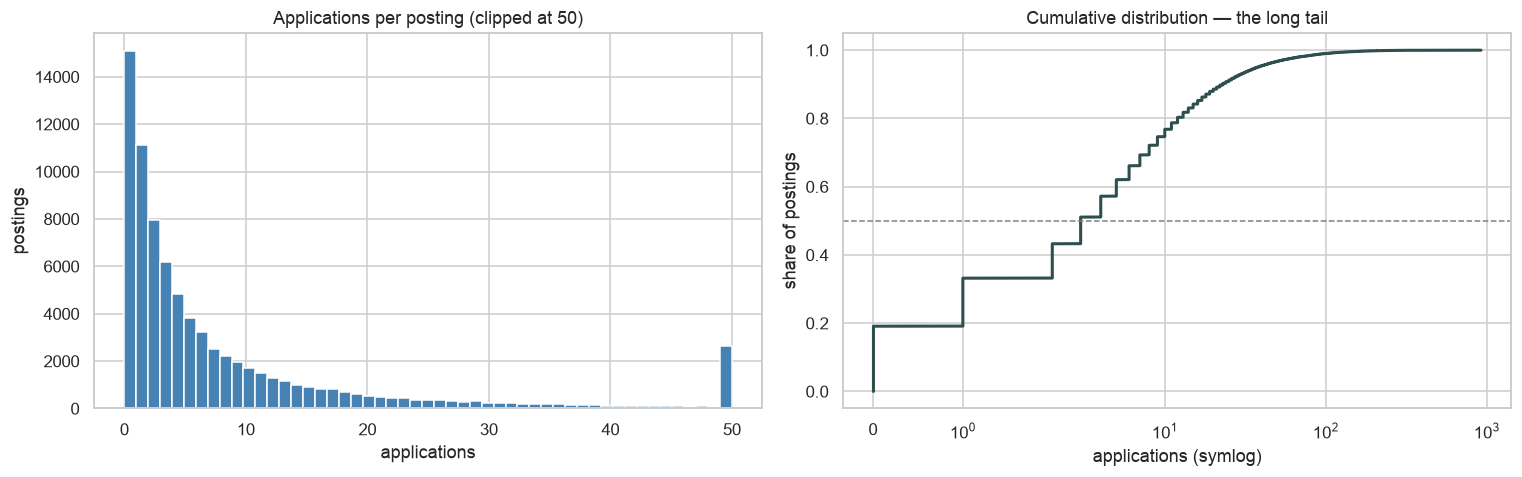

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].hist(first.applications.clip(0, 50), bins=51, color='steelblue')
axes[0].set_title('Applications per posting (clipped at 50)')
axes[0].set_xlabel('applications')
axes[0].set_ylabel('postings')

srt = np.sort(first.applications.values)
axes[1].plot(srt, np.arange(1, len(srt) + 1) / len(srt), lw=2, color='darkslategray')
axes[1].set_xscale('symlog')
axes[1].set_title('Cumulative distribution — the long tail')
axes[1].set_xlabel('applications (symlog)')
axes[1].set_ylabel('share of postings')
axes[1].axhline(0.5, ls='--', c='grey', lw=1)

plt.tight_layout()
plt.show()

The left panel is why medians are the only honest summary: the mode is **zero**, and the mean sits
out past the 70th percentile. The right panel shows how long the tail runs — a small number of
postings collect hundreds of applications and would dominate any average.

### 2.1 The same distribution, split by configuration

The pooled shape hides the thing the hirer needs: *different configurations have different
distributions*, not just different averages. Boxes are drawn without outliers and the axis is capped,
because the tail established above would otherwise flatten every box into a line.

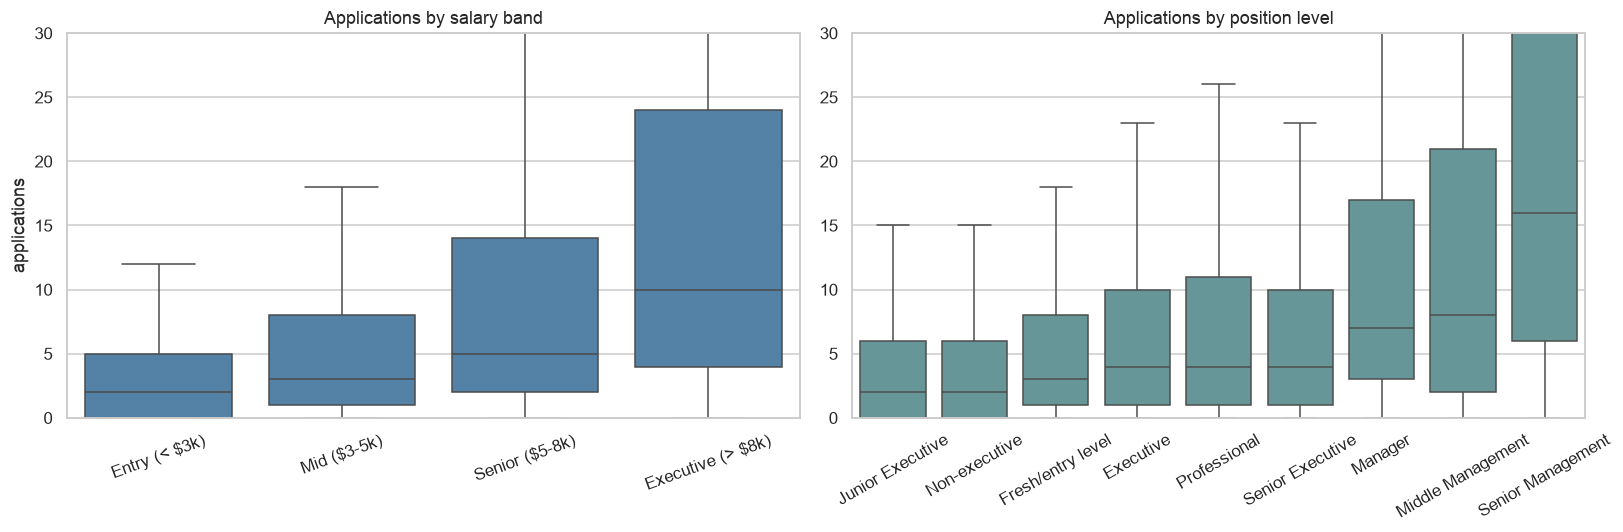

In [30]:
bands = [b for b in PAY_LABELS if b in first.pay_band.dropna().unique()]

lvl_order = (first.groupby('position_level', observed=True).applications
                  .median().sort_values().index.tolist())

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(data=first[first.pay_band.isin(bands)], x='pay_band', y='applications',
            order=bands, showfliers=False, color='steelblue', ax=axes[0])
axes[0].set_ylim(0, 30)
axes[0].set_title('Applications by pay band')
axes[0].set_xlabel('')
axes[0].set_ylabel('applications')
axes[0].tick_params(axis='x', rotation=20)

sns.boxplot(data=first, x='position_level', y='applications',
            order=lvl_order, showfliers=False, color='cadetblue', ax=axes[1])
axes[1].set_ylim(0, 30)
axes[1].set_title('Applications by position level')
axes[1].set_xlabel('')
axes[1].set_ylabel('')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

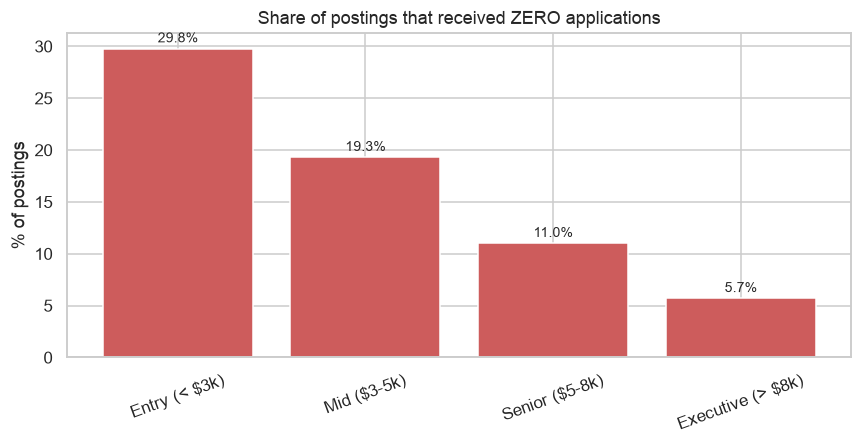

In [31]:
# The zero-applicant share is invisible in a boxplot but is the outcome the hirer cares about most.
zero_by_band = (first[first.pay_band.isin(bands)]
                .groupby('pay_band', observed=True)
                .applications.apply(lambda s: (s == 0).mean())
                .reindex(bands) * 100)

fig, ax = plt.subplots(figsize=(8, 4.2))
ax.bar(zero_by_band.index, zero_by_band.values, color='indianred')
ax.set_title('Share of postings that received ZERO applications')
ax.set_ylabel('% of postings')
ax.tick_params(axis='x', rotation=20)
for i, v in enumerate(zero_by_band.values):
    ax.text(i, v + 0.6, f'{v:.1f}%', ha='center', fontsize=9)
plt.tight_layout()
plt.show()

## 3. Response benchmarks by configuration

The core deliverable: for a configuration, what response did comparable postings actually get?
Same graceful-degradation pattern as Layer 1 — quote the finest grain that clears `MIN_N`, and
always report which grain was used.

In [32]:
def response_benchmark(frame, keys, min_n=MIN_N):
    out = frame.groupby(keys, observed=True).agg(
        n=('applications', 'size'),
        apps_p10=('applications', lambda s: s.quantile(.10)),
        apps_p50=('applications', 'median'),
        apps_p90=('applications', lambda s: s.quantile(.90)),
        zero_rate=('applications', lambda s: (s == 0).mean()),
        underfilled=('understaffed', 'mean'),
        views_p50=('views', 'median'),
    ).round(3)
    return out[out.n >= min_n].sort_values('n', ascending=False)


KEYS_3 = ['sector', 'position_level', 'pay_band']
KEYS_2 = ['sector', 'position_level']

resp_3 = response_benchmark(first, KEYS_3)
resp_2 = response_benchmark(first, KEYS_2)

for name, tbl in [('sector+level+band', resp_3), ('sector+level', resp_2)]:
    print(f'{name:20s} {len(tbl):4d} cells >= {MIN_N}, covering {tbl.n.sum()/len(first):.1%} of postings')

resp_3.head(10)

sector+level+band     420 cells >= 30, covering 91.3% of postings
sector+level          247 cells >= 30, covering 98.2% of postings


n  apps_p10  apps_p50  apps_p90  zero_rate  underfilled  views_p50
sector                           position_level    pay_band                                                                                
Admin / Secretarial              Junior Executive  Entry (< $3k)      1651       0.0       2.0      17.0      0.237        0.297       48.0
Building and Construction        Executive         Mid ($3-5k)        1381       0.0       2.0      12.0      0.182        0.396       83.0
Engineering                      Executive         Mid ($3-5k)        1370       0.0       2.0      12.1      0.223        0.304       52.0
Accounting / Auditing / Taxation Executive         Mid ($3-5k)        1304       0.0       5.0      20.0      0.142        0.213       83.0
Information Technology           Professional      Executive (> $8k)  1056       1.0       5.0      22.0      0.070        0.227       82.0
Admin / Secretarial              Fresh/entry level Entry (< $3k)      1017       0.0       4.0      26.0      0.153        0.238       75.0
                                 Non-executive     Entry (< $3k)       985       0.0       4.0      22.0      0.148        0.222       79.0
Engineering                      Junior Executive  Mid ($3-5k)         983       0.0       2.0      10.0      0.220        0.314       43.0
Admin / Secretarial              Executive         Mid ($3-5k)         979       1.0       8.0      35.0      0.080        0.122       87.0
Information Technology           Executive         Senior ($5-8k)      855       0.0       5.0      25.0      0.122        0.246       74.0

In [33]:
GLOBAL = {'n': len(first), 'apps_p10': first.applications.quantile(.10),
          'apps_p50': first.applications.median(), 'apps_p90': first.applications.quantile(.90),
          'zero_rate': (first.applications == 0).mean(), 'underfilled': first.understaffed.mean()}


def response_lookup(sector, position_level, pay_band=None):
    """Expected response for one configuration, degrading gracefully on thin cells."""
    if pay_band is not None and (sector, position_level, pay_band) in resp_3.index:
        return {'grain': 'sector + level + band', **resp_3.loc[(sector, position_level, pay_band)].to_dict()}
    if (sector, position_level) in resp_2.index:
        return {'grain': 'sector + level', **resp_2.loc[(sector, position_level)].to_dict()}
    return {'grain': 'all postings (no comparable cell)', **GLOBAL}


for q in [('Engineering', 'Executive', 'Mid ($3-5k)'),
          ('Information Technology', 'Professional', 'Executive (> $8k)'),
          ('Admin / Secretarial', 'Junior Executive', 'Entry (< $3k)')]:
    r = response_lookup(*q)
    print(f'{q[0]} / {q[1]} / {q[2]}')
    print(f'   grain={r["grain"]}  n={int(r["n"]):,}  '
          f'median={r["apps_p50"]:.0f} applications (P10-P90: {r["apps_p10"]:.0f}-{r["apps_p90"]:.0f})')
    print(f'   {r["zero_rate"]:.0%} got zero applicants, {r["underfilled"]:.0%} under-filled\n')

Engineering / Executive / Mid ($3-5k)
   grain=sector + level + band  n=1,370  median=2 applications (P10-P90: 0-12)
   22% got zero applicants, 30% under-filled

Information Technology / Professional / Executive (> $8k)
   grain=sector + level + band  n=1,056  median=5 applications (P10-P90: 1-22)
   7% got zero applicants, 23% under-filled

Admin / Secretarial / Junior Executive / Entry (< $3k)
   grain=sector + level + band  n=1,651  median=2 applications (P10-P90: 0-17)
   24% got zero applicants, 30% under-filled



                       n  apps_p10  apps_p50  apps_p90  zero_rate  underfilled
pay_band                                                                      
Entry (< $3k)      21928       0.0       2.0      12.0      0.298        0.433
Mid ($3-5k)        32734       0.0       3.0      19.0      0.193        0.313
Senior ($5-8k)     15423       0.0       5.0      29.0      0.110        0.185
Executive (> $8k)   8345       1.0      10.0      51.0      0.057        0.126


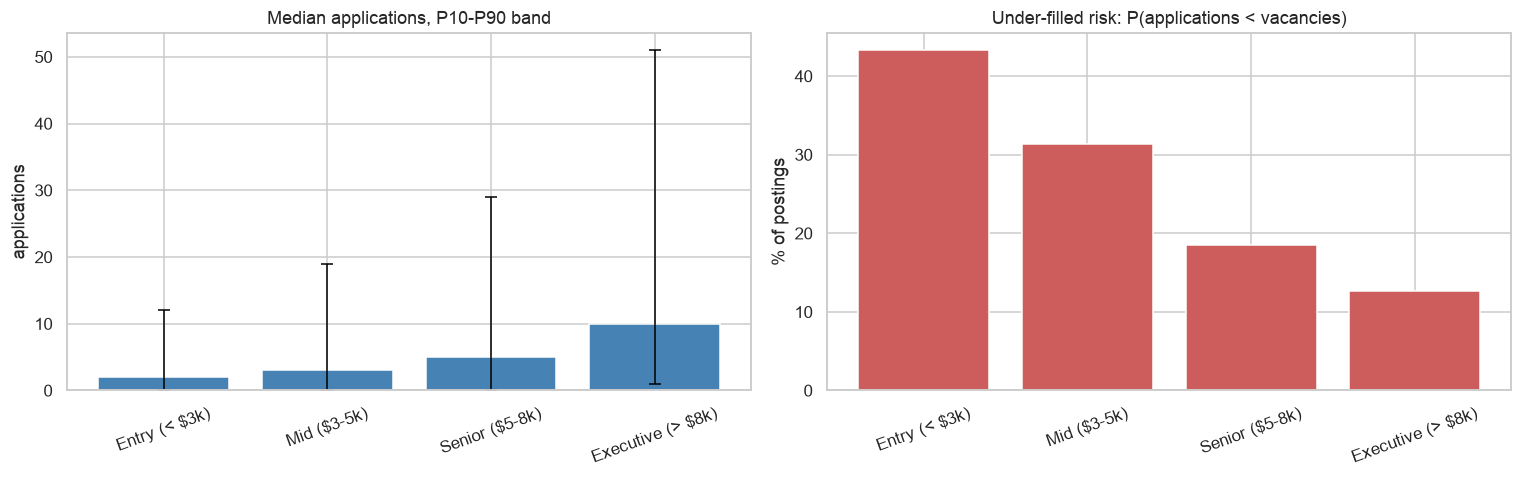

In [34]:
band_resp = first.groupby('pay_band', observed=True).agg(
    n=('applications', 'size'),
    apps_p10=('applications', lambda s: s.quantile(.10)),
    apps_p50=('applications', 'median'),
    apps_p90=('applications', lambda s: s.quantile(.90)),
    zero_rate=('applications', lambda s: (s == 0).mean()),
    underfilled=('understaffed', 'mean')).round(3)
print(band_resp.to_string())

order = PAY_LABELS
plot_df = band_resp.loc[[b for b in order if b in band_resp.index]]

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))
x = np.arange(len(plot_df))
axes[0].bar(x, plot_df.apps_p50, color='steelblue')
axes[0].errorbar(x, plot_df.apps_p50,
                 yerr=[plot_df.apps_p50 - plot_df.apps_p10, plot_df.apps_p90 - plot_df.apps_p50],
                 fmt='none', ecolor='black', capsize=4, lw=1)
axes[0].set_xticks(x); axes[0].set_xticklabels(plot_df.index, rotation=20)
axes[0].set_title('Median applications, P10-P90 band')
axes[0].set_ylabel('applications')

axes[1].bar(x, plot_df.underfilled * 100, color='indianred')
axes[1].set_xticks(x); axes[1].set_xticklabels(plot_df.index, rotation=20)
axes[1].set_title('Under-filled risk: P(applications < vacancies)')
axes[1].set_ylabel('% of postings')

plt.tight_layout()
plt.show()

Pay dominates response. Entry (< \$3k) postings get a median of **2** applicants and are
under-filled **43%** of the time; Executive (> \$8k) postings get a median of **10** and are
under-filled **13%**.

These bands are `pay_band` (§1.5) — cut on the actual midpoint, not the advertised ceiling — so
the comparison is between postings that really do pay differently. Layer 1's dollar percentiles
remain the finer instrument; bands are used here because stratification needs discrete groups.

## 4. The funnel — is it reach or is it conversion?

Applications are the product of two different things: how many people **saw** the posting, and what
share of them **applied**. They have different fixes. Low reach is a visibility problem; low
conversion means people looked at the offer and declined it.

In [35]:
first['conversion'] = first.applications / first.views.replace(0, np.nan)

funnel = first.groupby('pay_band', observed=True).agg(
    n=('views', 'size'),
    views_p50=('views', 'median'),
    conversion_p50=('conversion', 'median')).round(4)
funnel['conversion_%'] = (funnel.conversion_p50 * 100).round(2)
print(funnel.drop(columns='conversion_p50').to_string())

                       n  views_p50  conversion_%
pay_band                                         
Entry (< $3k)      21928       53.0          3.23
Mid ($3-5k)        32734       61.0          5.08
Senior ($5-8k)     15423       78.0          7.14
Executive (> $8k)   8345      116.0          8.89


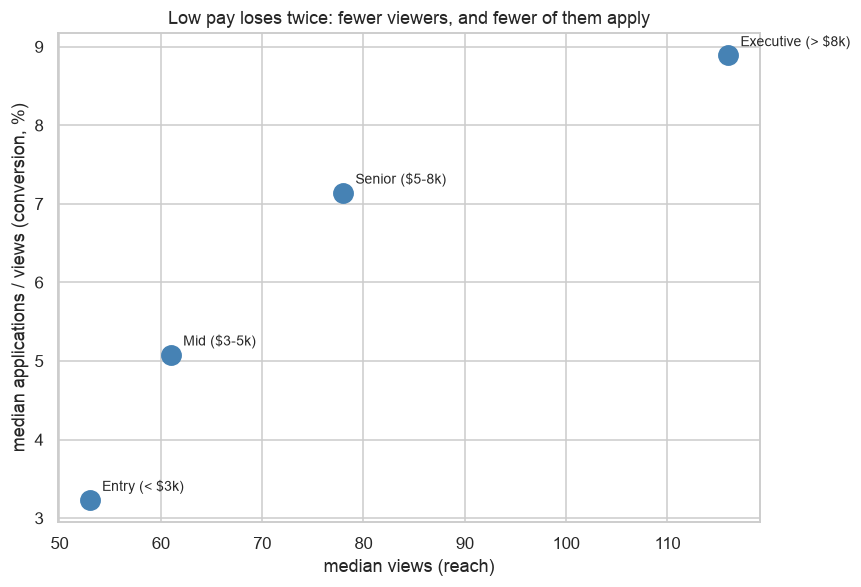

In [36]:
fig, ax = plt.subplots(figsize=(8, 5.5))
sub = funnel.loc[[b for b in order if b in funnel.index]]
ax.scatter(sub.views_p50, sub.conversion_p50 * 100, s=160, color='steelblue', zorder=3)
for label, row in sub.iterrows():
    ax.annotate(label, (row.views_p50, row.conversion_p50 * 100),
                textcoords='offset points', xytext=(8, 6), fontsize=9)
ax.set_xlabel('median views (reach)')
ax.set_ylabel('median applications / views (conversion, %)')
ax.set_title('Low pay loses twice: fewer viewers, and fewer of them apply')
plt.tight_layout()
plt.show()

The two effects compound rather than trade off. Entry-band postings get about **half** the views of
Executive-band ones (53 vs 116) *and* convert at roughly **a third** the rate (3.2% vs 8.9%).

For the dashboard this is the more actionable split: if a configuration's problem is conversion,
raising the salary is the lever. If it is reach, the sector is simply crowded — which is what
Layer 1's competition-density measure quantifies.

## 5. Repost risk — where the marginal view is actively wrong

Now the stated business outcome. The naive cut says: **require more experience, get fewer
reposts.** Taken at face value that advises the hirer to raise the experience bar to protect the
fill — which would be a bad thing for a dashboard to imply.

In [37]:
repost_pool = repost_pool.copy()
repost_pool['yrs'] = pd.cut(repost_pool.seniority_years, YR_BINS, labels=YR_LABELS)

marginal = repost_pool.groupby('yrs', observed=True).agg(
    n=('is_repost', 'size'), repost_rate=('is_repost', 'mean')).round(3)
print('MARGINAL -- repost rate by required years:')
print(marginal.to_string())
print('\nReads as: more experience -> fewer reposts. Now hold pay fixed.')

MARGINAL -- repost rate by required years:
         n  repost_rate
yrs                    
0     9757        0.202
1    25848        0.174
2    21085        0.200
3    15919        0.185
4-5  15707        0.156
6-8   4552        0.138
9+    3160        0.117

Reads as: more experience -> fewer reposts. Now hold pay fixed.


STRATIFIED -- repost rate by required years, within pay band:
yrs                   0     1     2     3   4-5   6-8    9+
pay_band                                                   
Entry (< $3k)      20.6  17.4  22.9  25.2  22.9   NaN   NaN
Mid ($3-5k)        19.6  16.9  19.3  19.0  17.1  16.2   9.2
Senior ($5-8k)     20.1  18.7  17.0  16.2  15.3  15.3  13.2
Executive (> $8k)   6.4  17.2  17.2  12.9  12.4  11.8  11.5

Cell counts behind it (NaN above = suppressed, below 30):
yrs                   0      1      2     3   4-5   6-8    9+
pay_band                                                     
Entry (< $3k)      5824  13664   5704  1661   441    27    13
Mid ($3-5k)        3029  10281  12312  8789  4971   419   260
Senior ($5-8k)      477   1382   2576  4389  7189  1719   644
Executive (> $8k)   173    267    395  1033  3066  2360  2224


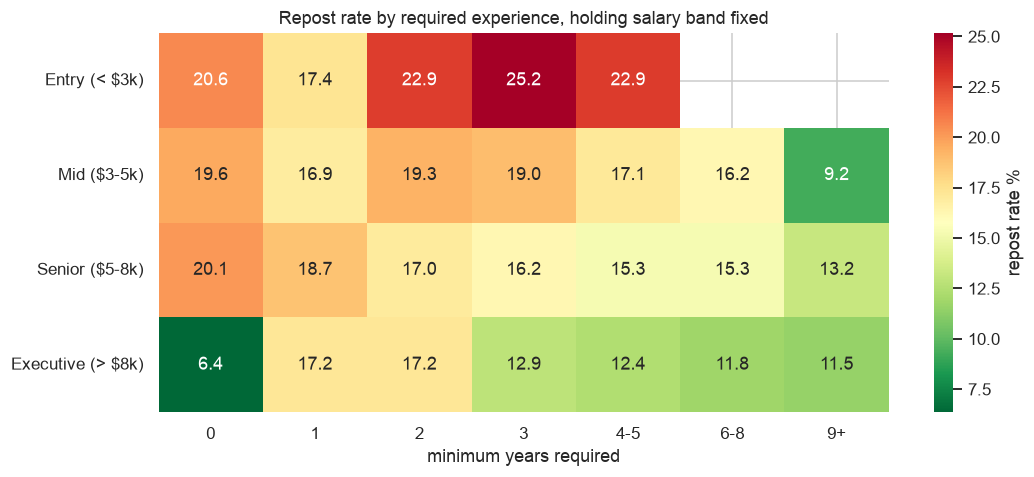

In [38]:
strat = pd.crosstab(repost_pool.pay_band, repost_pool.yrs,
                    values=repost_pool.is_repost, aggfunc='mean')
counts = pd.crosstab(repost_pool.pay_band, repost_pool.yrs)
strat = strat.where(counts >= MIN_N)          # suppress cells too thin to read
strat = strat.loc[[b for b in order if b in strat.index]]

print('STRATIFIED -- repost rate by required years, within pay band:')
print((strat * 100).round(1).to_string())
print('\nCell counts behind it (NaN above = suppressed, below ' f'{MIN_N}):')
print(counts.loc[strat.index].to_string())

fig, ax = plt.subplots(figsize=(10, 4.5))
sns.heatmap(strat * 100, annot=True, fmt='.1f', cmap='RdYlGn_r',
            cbar_kws={'label': 'repost rate %'}, ax=ax)
ax.set_title('Repost rate by required experience, holding pay band fixed')
ax.set_xlabel('minimum years required')
ax.set_ylabel('')
plt.tight_layout()
plt.show()

In [39]:
lo, hi = 'Entry (< $3k)', 'Mid ($3-5k)'
for band in [lo, hi]:
    if band in strat.index:
        row = strat.loc[band].dropna()
        print(f'{band:18s} {row.index[0]}yr: {row.iloc[0]:.1%}  ->  {row.index[-1]}yr: {row.iloc[-1]:.1%}'
              f'   ({"RISES" if row.iloc[-1] > row.iloc[0] else "falls"} with experience demanded)')

Entry (< $3k)      0yr: 20.6%  ->  4-5yr: 22.9%   (RISES with experience demanded)
Mid ($3-5k)        0yr: 19.6%  ->  9+yr: 9.2%   (falls with experience demanded)


The marginal trend dissolves, and inside the Entry band it **reverses**: asking for more experience
at low pay is associated with *more* reposting, peaking at 3 years. In the Mid and Senior
bands the relationship runs the other way.

The marginal decline was composition: senior-experience roles are concentrated in higher pay
bands, and those bands repost less. Aggregating across bands mixes the two and inverts the sign —
a textbook Simpson's paradox, and the reason a dashboard must not ship the marginal cut.

**The danger zone is high experience demanded at low pay.**

**Two honest qualifications on the table above.**

1. The Entry band's tail is thin. Its 6–8 and 9+ cells were suppressed at 27 and 13 postings.
   Employers rarely ask for a decade of experience at under \$3k, which is itself informative — but
   it means the rise is established over the 0–5 year span only, not across the full range. The
   *direction* is what survives, and §6 confirms it on all 95,289 postings.
2. The Executive band's low-experience cells are thin and erratic (n = 173 at 0 years, 267 at 1
   year) and should not be read as a trend. Well-paid roles asking almost no experience are rare
   enough that the cell is noisy; it does not affect the main finding.

## 6. Confirming it with a model

The stratified table is convincing but eyeballed. A logistic model with a `years x pay_band`
interaction tests it directly. The coefficient on `yrs_c` is the effect of one more required year
*within the reference (Entry) band*; each interaction term is how that effect shifts in the
other bands.

In [41]:
model_df = repost_pool[repost_pool.pay_band.notna()].copy()
for col in ['pay_band', 'position_level']:
    model_df[col] = model_df[col].astype(str)   # drop unused categories -> avoids a singular design
model_df['yrs_c'] = model_df.seniority_years.clip(0, 15).astype(float)
model_df['reposted'] = model_df.is_repost.astype(int)

fit = smf.logit(
    'reposted ~ yrs_c * C(pay_band, Treatment(reference="Entry (< $3k)")) + C(position_level)',
    data=model_df).fit(disp=0)

terms = [t for t in fit.params.index if 'yrs_c' in t]
summary = pd.DataFrame({
    'coef': fit.params[terms],
    'odds_ratio': np.exp(fit.params[terms]),
    'p_value': fit.pvalues[terms],
}).round(4)
summary.index = [t.replace('C(pay_band, Treatment(reference="Entry (< $3k)"))', 'band')
                  .replace('[T.', '=').replace(']', '') for t in summary.index]
print(f'n = {int(fit.nobs):,}   pseudo-R2 = {fit.prsquared:.4f}\n')
print(summary.to_string())

n = 95,289   pseudo-R2 = 0.0096

                                coef  odds_ratio  p_value
yrs_c                         0.0687      1.0711      0.0
yrs_c:band=Executive (> $8k) -0.0884      0.9154      0.0
yrs_c:band=Mid ($3-5k)       -0.1137      0.8925      0.0
yrs_c:band=Senior ($5-8k)    -0.1211      0.8860      0.0


In [42]:
base = fit.params['yrs_c']
print('Effect of one additional required year, by band (log-odds of reposting):\n')
print(f'{"Entry (< $3k)":20s} {base:+.4f}   <- reference')
for t in terms:
    if ':' in t:
        band = t.split('T.')[1].rstrip(']')
        print(f'{band:20s} {base + fit.params[t]:+.4f}')

Effect of one additional required year, by band (log-odds of reposting):

Entry (< $3k)        +0.0687   <- reference
Executive (> $8k)    -0.0197
Mid ($3-5k)          -0.0451
Senior ($5-8k)       -0.0524


The model confirms the stratified table. Within the Entry band the years coefficient is
**positive and significant** (+0.069, p < 0.0001) — each extra year of required experience raises
the odds of reposting by about 7%. All three interaction terms are **negative with p < 0.0001**, so
in every better-paid band the effect flips sign.

**A necessary caveat: pseudo-R² is 0.010.** The model explains almost none of the variance in
reposting. That is not a defect to hide — it is the finding. Whether an employer reposts is driven
overwhelmingly by factors this dataset does not contain (hiring urgency, candidate quality,
internal process). What the model establishes is the **direction and significance of an
interaction**, not an ability to predict which postings will be reposted. The dashboard should
present this as a risk factor, never as a prediction.

## 7. What Layer 2 establishes, and what it cannot

**Established:**

* Expected applicant response for a configuration — median and P10–P90, plus zero-applicant and
  under-filled rates, at `sector × position_level × pay_band` where the cell supports it.
* Pay drives response through **both** reach and conversion, and the two compound.
* Requiring more experience is associated with **more** reposting when pay is low, and slightly
  less when pay is adequate. The marginal cut says the opposite and is a composition artefact.

**Cannot be established from this data:**

* **Anything seasonal or recent.** The cohort is a single window, Mar–Jun 2023. Layer 1 covers 15
  months; Layer 2 does not, and no amount of care fixes that.
* **Causation.** These are associations. A configuration is chosen by an employer who knows things
  about the role that we do not.
* **Whether a role actually filled.** We observe applications, not hires. "Under-filled" is a
  necessary-not-sufficient proxy.
* **Prediction of reposting.** Pseudo-R² 0.010 — see §6.

**Coverage note.** Every filter in §1 is documented with its row cost: 118,749 complete-counter
postings, 96,028 after the 30-day restriction, 78,942 first-cycle. Nothing was dropped silently.